In [19]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [20]:
df = pl.read_parquet("/home/harry/code/corporate-bias/data/model-effects.parquet")
df = (
    df
    .filter(pl.col("comparison_set") == "search-engine")
    .filter(pl.col("measurand") == "critique_aversion_score")
)
pdf = (
    df
    .select(["term", "subsample_index", "coeff", "std_err", "p_value"])
    .to_pandas()
)
print(df.schema)

Schema({'term': String, 'coeff': Float64, 'std_err': Float64, 'p_value': Float64, 'y_standardized': Float64, 'y_std': Float64, 'r_squared': Float64, 'r_squared_adj': Float64, 'measurand': String, 'assay': String, 'comparison_set': String, 'subsample_index': Int32, 'subsample_size': Float64})


In [21]:
coef = (
    pdf
    .pivot_table(
        index="term",
        columns="subsample_index",
        values="coeff",
        aggfunc="mean",
    )
    .sort_index(axis=1)
)

pvals = (
    pdf
    .pivot_table(
        index="term",
        columns="subsample_index",
        values="p_value",
        aggfunc="mean",
    )
    .reindex(index=coef.index, columns=coef.columns)
)

coef.head()

subsample_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
term,,,,,,,,,,,,,,,,,,,,
"C(entity, Sum)[S.Baidu]",-0.149243,-0.153015,-0.156929,-0.134349,-0.148057,-0.137859,-0.147216,-0.153622,-0.143217,-0.137101,-0.141694,-0.155728,-0.144742,-0.140806,-0.136995,-0.139136,-0.141004,-0.132800,-0.142356,-0.133486
"C(entity, Sum)[S.DuckDuckGo]",0.030058,0.021547,0.039281,0.012901,0.026756,0.023695,0.025638,0.031007,0.032553,0.023566,0.032209,0.026543,0.038075,0.017873,0.023521,0.024308,0.034165,0.030532,0.043823,0.015699
"C(entity, Sum)[S.Ecosia]",0.139194,0.171880,0.142520,0.151249,0.143878,0.155536,0.149766,0.149883,0.163957,0.146772,0.146905,0.154118,0.146770,0.148658,0.155615,0.151411,0.154621,0.155564,0.144091,0.143283
"C(entity, Sum)[S.Google]",-0.008594,-0.020444,-0.020086,-0.021555,-0.014940,-0.010782,-0.017984,-0.016804,-0.020957,-0.004422,-0.015365,-0.016002,-0.021466,-0.015548,-0.022587,-0.017647,-0.018379,-0.011873,-0.026363,-0.028396
"C(entity, Sum)[S.Haosou]",-0.081225,-0.078891,-0.071909,-0.070193,-0.065860,-0.078678,-0.075432,-0.076851,-0.077662,-0.075626,-0.080926,-0.071043,-0.075515,-0.069649,-0.075087,-0.072330,-0.079057,-0.081572,-0.071949,-0.067164


(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Run-to-run similarity of absolute-effect ranks'}, xlabel='Subsample run', ylabel='Subsample run'>)

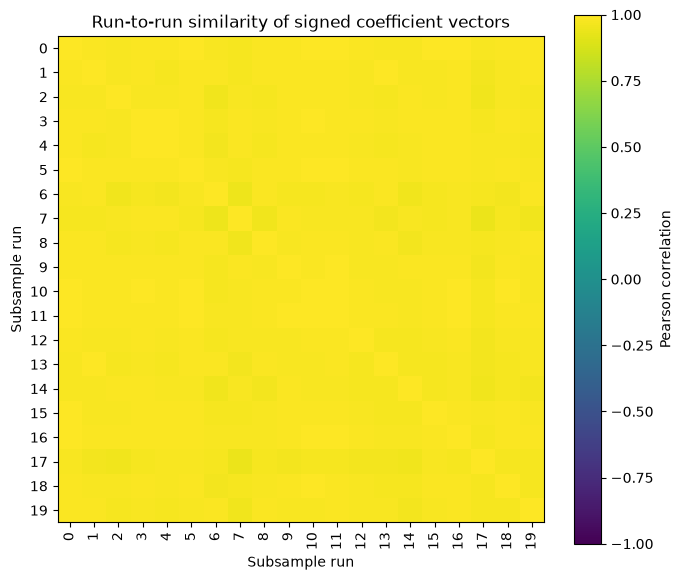

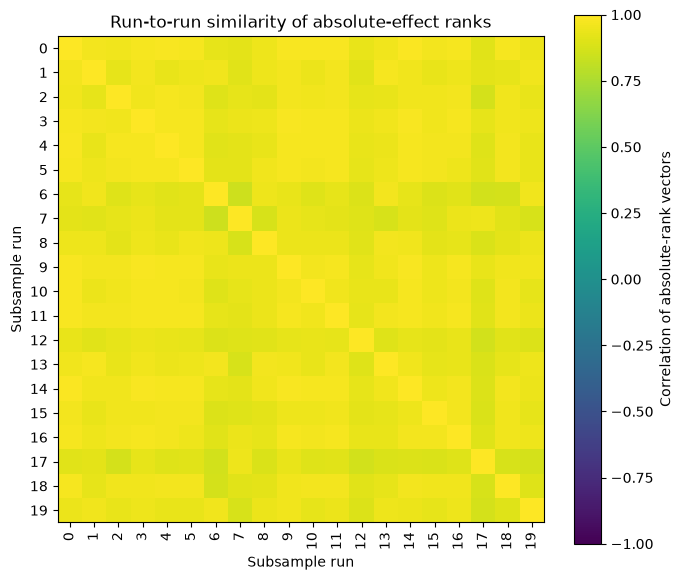

In [22]:
# Signed coefficient-vector similarity across subsamples
signed_corr = coef.corr(method="pearson", min_periods=5)

# Rank stability of absolute effects: are the same predictors large across runs?
abs_ranks = coef.abs().rank(axis=0, ascending=False, method="average")
rank_corr = abs_ranks.corr(method="pearson", min_periods=5)

def plot_corr_matrix(corr, title, cbar_label):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, interpolation="nearest")

    ax.set_xticks(np.arange(corr.shape[1]))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(np.arange(corr.shape[0]))
    ax.set_yticklabels(corr.index)

    ax.set_title(title)
    ax.set_xlabel("Subsample run")
    ax.set_ylabel("Subsample run")

    fig.colorbar(im, ax=ax, label=cbar_label)
    fig.tight_layout()
    return fig, ax

plot_corr_matrix(
    signed_corr,
    "Run-to-run similarity of signed coefficient vectors",
    "Pearson correlation",
)

plot_corr_matrix(
    rank_corr,
    "Run-to-run similarity of absolute-effect ranks",
    "Correlation of absolute-rank vectors",
)

In [26]:
stats = pd.DataFrame(index=coef.index)

stats["n_runs"] = coef.notna().sum(axis=1)
stats["mean_coeff"] = coef.mean(axis=1)
stats["median_coeff"] = coef.median(axis=1)
stats["sd_coeff"] = coef.std(axis=1)
stats["q25_coeff"] = coef.quantile(0.25, axis=1)
stats["q75_coeff"] = coef.quantile(0.75, axis=1)
stats["iqr_coeff"] = stats["q75_coeff"] - stats["q25_coeff"]
stats["min_coeff"] = coef.min(axis=1)
stats["max_coeff"] = coef.max(axis=1)
stats["range_coeff"] = stats["max_coeff"] - stats["min_coeff"]

stats["crosses_zero"] = (stats["min_coeff"] < 0) & (stats["max_coeff"] > 0)
stats["prop_positive"] = coef.gt(0).sum(axis=1) / coef.notna().sum(axis=1)

stats["cv_abs_mean"] = stats["sd_coeff"] / (stats["mean_coeff"].abs() + 1e-12)

stats["mean_abs_rank"] = abs_ranks.mean(axis=1)
stats["sd_abs_rank"] = abs_ranks.std(axis=1)

stats["prop_p_lt_05"] = pvals.lt(0.05).sum(axis=1) / pvals.notna().sum(axis=1)

# A practical instability ordering.
unstable = stats.sort_values(
    ["crosses_zero", "sd_abs_rank", "sd_coeff", "range_coeff"],
    ascending=[False, False, False, False],
)

unstable.tail(30)

,n_runs,mean_coeff,median_coeff,sd_coeff,q25_coeff,q75_coeff,iqr_coeff,min_coeff,max_coeff,range_coeff,crosses_zero,prop_positive,cv_abs_mean,mean_abs_rank,sd_abs_rank,prop_p_lt_05
term,,,,,,,,,,,,,,,,
"C(model, Sum)[S.grok-4.3]",20,-0.098894,-0.099322,0.012318,-0.101740,-0.089938,0.011802,-0.125219,-0.076317,0.048902,False,0.0,0.124554,27.10,2.845125,1.00
"C(model, Sum)[S.hy3]",20,-0.052346,-0.051437,0.008737,-0.055585,-0.048263,0.007322,-0.072861,-0.038471,0.034390,False,0.0,0.166915,38.75,2.750598,0.00
[model] qwen3.7-plus,20,-0.042974,-0.044036,0.008612,-0.049122,-0.035676,0.013446,-0.059716,-0.029209,0.030508,False,0.0,0.200405,41.95,2.723678,0.00
"C(model, Sum)[S.mimo-v2.5]",20,0.135674,0.135573,0.015489,0.124310,0.145035,0.020725,0.111649,0.166835,0.055186,False,1.0,0.114162,19.05,2.543826,1.00
[entity] Yandex,20,0.066492,0.065506,0.007476,0.060847,0.071482,0.010635,0.052127,0.081081,0.028954,False,1.0,0.112442,35.20,2.440880,1.00
"C(entity, Sum)[S.Startpage]",20,0.104265,0.104478,0.008470,0.097892,0.109309,0.011417,0.091318,0.118586,0.027268,False,1.0,0.081236,25.45,2.438183,1.00
"C(model, Sum)[S.deepseek-v4-pro]",20,0.086632,0.084368,0.010794,0.078951,0.094077,0.015126,0.072625,0.112333,0.039708,False,1.0,0.124597,30.80,2.397367,0.95
"C(entity, Sum)[S.Google]",20,-0.017510,-0.017815,0.005751,-0.021084,-0.015259,0.005826,-0.028396,-0.004422,0.023974,False,0.0,0.328462,51.00,2.247806,0.00
"C(entity, Sum)[S.Sogou]",20,0.110648,0.110791,0.008809,0.105245,0.115194,0.009948,0.093701,0.128188,0.034487,False,1.0,0.079616,24.25,1.943275,1.00


In [27]:
print(df.filter(pl.col("term") == "Q('model_gemini-3.5-flash_affiliated_entity')[T.True]").select(["term", "coeff", "std_err", "p_value"]).to_pandas().to_string())

                                                     term     coeff   std_err   p_value
0   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.203156  0.148651  0.171936
1   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.275377  0.169144  0.103722
2   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.353771  0.168150  0.035554
3   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.241200  0.135249  0.074728
4   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.159507  0.146345  0.275917
5   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.223098  0.134627  0.097697
6   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.162672  0.148913  0.274835
7   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.248407  0.133560  0.063097
8   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.218789  0.133756  0.102106
9   Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.239018  0.134813  0.076437
10  Q('model_gemini-3.5-flash_af